 Conjunto de dados: 1200 observações de calçados femininos de numeração 35 coletadas do site https://www.dafiti.com.br 
 Objetivo: Avaliar a possibilidade de agrupamento entre as observações a partir do conjunto de dados Bag of Words originado do conjunto original.


C:\Users\catit\AppData\Local\Temp\ipykernel_11820\3114640831.py:518: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(



 🔎 ANÁLISE DO PCA: O QUE OS EIXOS REPRESENTAM?
Como estamos avaliando preços, veja qual variável puxa o gráfico para cada lado:

🔹 COMPONENTE 1 (Eixo X):
   > Preço Parcelado: +0.583 -> Força Positiva (Direita/Cima)
   > Preço Pix: +0.581 -> Força Positiva (Direita/Cima)
   > Preço Original: +0.568 -> Força Positiva (Direita/Cima)

🔹 COMPONENTE 2 (Eixo Y):
   > Preço Original: +0.821 -> Força Positiva (Direita/Cima)
   > Preço Parcelado: -0.358 -> Força Negativa (Esquerda/Baixo)
   > Preço Pix: -0.444 -> Força Negativa (Esquerda/Baixo)

 RELATÓRIO DE PERFIL DOS GRUPOS (POR PREÇO)

🟢 PERFIL DO GRUPO 0 - Categoria: Básico (Entrada)
---------------------------------------------
Total de produtos no segmento: 896 (74.7%)

💰 Ticket Médio do Segmento:
  > Preço Original: R$ 167.98
  > Preço Pix: R$ 114.10
  > Preço Parcelado: R$ 122.42

🎨 Top 3 Cores do Segmento:
  > Preto: 248 unidades
  > Marrom: 189 unidades
  > Bege: 83 unidades

🏷️ Top 3 Marcas do Segmento:
  > Vizzano: 157 unidades
  

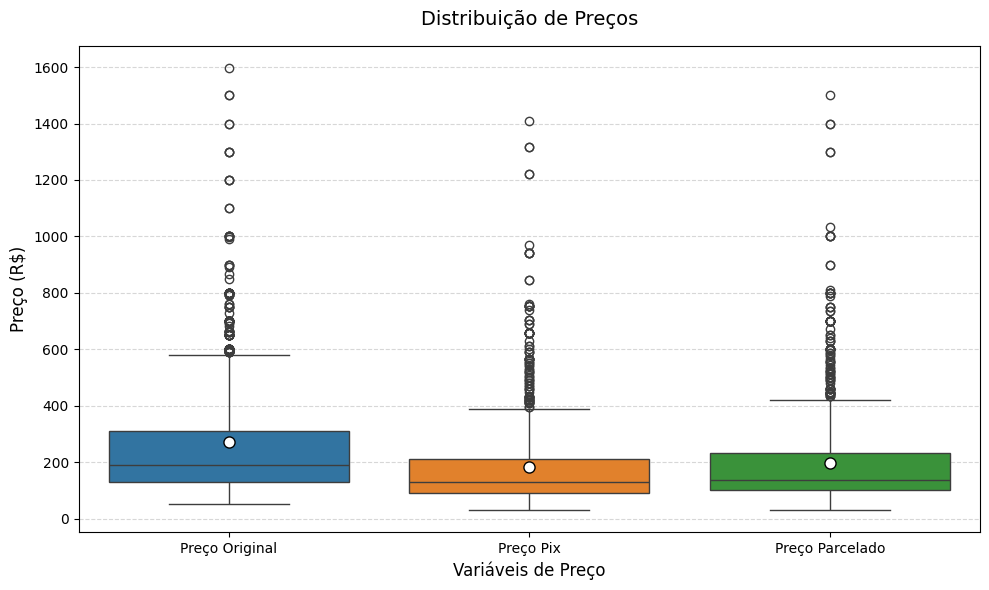

In [1]:
import os                      # Interação com o sistema operacional (caminhos de pastas/arquivos)
import io                      # Manipulação de fluxos de dados (usado para converter gráficos em imagens)
import base64                  # Codificação de imagens em texto (para embutir gráficos no HTML)
import warnings                # Controle de avisos (para ocultar avisos desnecessários do sklearn)
import pandas as pd            # Manipulação e análise de tabelas de dados (DataFrames)
import numpy as np             # Computação numérica e matrizes
import matplotlib.pyplot as plt # Criação de gráficos e visualização de dados
import seaborn as sns          # Visualização estatística avançada baseada no matplotlib
from wordcloud import WordCloud # Geração da nuvem de palavras
from sklearn.cluster import KMeans # Algoritmo de agrupamento (clustering)
from sklearn.decomposition import PCA # Redução de dimensionalidade para visualização
from sklearn.preprocessing import StandardScaler # Normalização de dados (essencial para o KMeans)
from sklearn.impute import SimpleImputer # Tratamento de valores faltantes (NaN) nos dados
import builtins

# ==========================================================
# SISTEMA AUTOMÁTICO DE RELATÓRIO HTML
# ==========================================================

html_parts = []

# ------------------------------
# Captura automática de print()
# ------------------------------

html_parts = []

# buffer contínuo de textos
texto_buffer = []

print_original = print


def flush_text_buffer():
    """
    Junta todos os prints em um único bloco HTML
    """

    global texto_buffer

    if texto_buffer:

        texto_unico = "\n".join(texto_buffer)

        html_parts.append(f"""
        <pre style="
            background:white;
            padding:20px;
            border-radius:10px;
            border-left:5px solid #4CAF50;
            overflow-x:auto;
            white-space:pre-wrap;
            line-height:1.6;
            box-shadow:0px 2px 8px rgba(0,0,0,0.05);
        ">
{texto_unico}
        </pre>
        """)

        texto_buffer = []


def print_html(*args, **kwargs):

    texto = " ".join(str(arg) for arg in args)

    # terminal continua normal
    print_original(*args, **kwargs)

    # acumula texto
    texto_buffer.append(texto)


builtins.print = print_html

# ------------------------------
# Converte figura para Base64
# ------------------------------

def fig_to_base64(fig):

    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format='png',
        bbox_inches='tight'
    )

    buffer.seek(0)

    imagem_base64 = base64.b64encode(
        buffer.read()
    ).decode('utf-8')

    buffer.close()

    return imagem_base64


# ------------------------------
# Salva gráfico no HTML
# ------------------------------
def imprimir_tabela_markdown(titulo, cabecalhos, linhas):
    print(f"{titulo}\n")
    larguras = [len(str(c)) for c in cabecalhos]
    for linha in linhas:
        for i, valor in enumerate(linha):
            larguras[i] = max(larguras[i], len(str(valor)))

    linha_cabecalho = " | ".join(str(c).ljust(l) for c, l in zip(cabecalhos, larguras))
    print(f"| {linha_cabecalho} |")

    separador = " | ".join("-" * l for l in larguras)
    print(f"| {separador} |")

    for linha in linhas:
        linha_formatada = " | ".join(str(v).ljust(l) for v, l in zip(linha, larguras))
        print(f"| {linha_formatada} |")
        
    print("\n" + "="*80 + "\n")
    
def salvar_figura(fig, titulo="Gráfico"):

    # antes de inserir imagem,
    # descarrega todos os prints acumulados
    flush_text_buffer()

    imagem = fig_to_base64(fig)

    html = f"""
    <div style="margin-top:40px; margin-bottom:40px;">

        <h2 style="
            font-family:Arial;
            color:#222;
            border-bottom:2px solid #ddd;
            padding-bottom:10px;
        ">
            {titulo}
        </h2>

        <img 
            src="data:image/png;base64,{imagem}"
            style="
                width:100%;
                max-width:1200px;
                border-radius:12px;
                border:1px solid #ccc;
                background:white;
                padding:10px;
                box-shadow:0px 2px 10px rgba(0,0,0,0.08);
            "
        >

    </div>
    """

    html_parts.append(html)

    plt.close(fig)


# ------------------------------
# Adiciona HTML externo no relatório
# ------------------------------

def adicionar_html_externo(caminho_html, titulo="Visualização"):

    flush_text_buffer()

    with open(caminho_html, "r", encoding="utf-8") as f:
        conteudo_html = f.read()

    # ESCAPA o HTML para evitar quebrar o srcdoc
    conteudo_html = conteudo_html.replace("&", "&amp;") \
                                 .replace("<", "&lt;") \
                                 .replace(">", "&gt;") \
                                 .replace('"', "&quot;") \
                                 .replace("'", "&#39;")

    html = f"""
    <div style="margin-top:40px; margin-bottom:40px;">

        <h2 style="
            font-family:Arial;
            color:#222;
            border-bottom:2px solid #ddd;
            padding-bottom:10px;
        ">
            {titulo}
        </h2>

        <div style="
            width:100%;
            height:900px;
            border:1px solid #ccc;
            border-radius:12px;
            overflow:auto;
            background:white;
            box-shadow:0px 2px 10px rgba(0,0,0,0.08);
        ">

            <iframe
                srcdoc="{conteudo_html}"
                width="100%"
                height="100%"
                style="border:none;"
            ></iframe>

        </div>

    </div>
    """

    html_parts.append(html)


# ------------------------------
# Gera HTML Final
# ------------------------------
def salvar_html(nome_arquivo="relatorio_dafiti.html"):

    flush_text_buffer()

    # garante segurança caso não existam
    tab1 = html_parts[0] if len(html_parts) > 0 else ""
    tab2 = html_parts[1] if len(html_parts) > 1 else ""

    # 👉 ABA 3 NÃO pode incluir os anteriores
    # removemos os dois primeiros elementos
    conteudo_relatorio = ''.join(html_parts[2:])

    html_final = f"""
    <!DOCTYPE html>
    <html lang="pt-br">

    <head>
        <meta charset="UTF-8">
        <title>Agrupamento Dafiti</title>

        <style>
            body {{
                font-family: Arial, sans-serif;
                margin: 0;
                background: #f4f4f4;
                color: #222;
            }}

            h1 {{
                padding: 20px 40px;
            }}

            .tabs {{
                display: flex;
                cursor: pointer;
                background: #222;
                color: white;
            }}

            .tab {{
                padding: 15px;
                flex: 1;
                text-align: center;
                background: #333;
            }}

            .tab:hover {{
                background: #444;
            }}

            .tab-content {{
                display: none;
                padding: 20px;
            }}

            .tab-content.active {{
                display: block;
            }}
        </style>

        <script>
            function openTab(tabId) {{
                document.querySelectorAll('.tab-content').forEach(t => t.classList.remove('active'));
                document.getElementById(tabId).classList.add('active');
            }}
        </script>
    </head>

    <body>

        <h1>📊 Análise de agrupamento para calçados femininos a partir de análise textual NLP</h1>
        <h2 class="subtitle"> Beatriz Vicentini</h2>
        <div class="tabs">
            <div class="tab" onclick="openTab('tab1')">t-SNE Bag of Words</div>
            <div class="tab" onclick="openTab('tab2')">t-SNE TF-IDF</div>
            <div class="tab" onclick="openTab('tab3')">Relatório</div>
        </div>

        <div id="tab1" class="tab-content active">
            {tab1}
        </div>

        <div id="tab2" class="tab-content">
            {tab2}
        </div>

        <div id="tab3" class="tab-content">
            {conteudo_relatorio}
        </div>

    </body>
    </html>
    """

    with open(nome_arquivo, "w", encoding="utf-8") as f:
        f.write(html_final)

    print_original(f"\n✅ Relatório HTML salvo em: {nome_arquivo}")





# Configurações Iniciais
pasta_atual = os.getcwd()

# 2. Sobe um nível a partir da pasta do script e entra em 'WebScrapping'
caminho_dados = os.path.abspath(os.path.join(pasta_atual, '..', 'WebScrapping', '20260412_DadosDafiti.csv'))

# 3. Carrega o arquivo
df = pd.read_csv(caminho_dados)



# ==========================================================
# ADICIONA VISUALIZAÇÕES t-SNE
# ==========================================================

caminho_tsne_bow = os.path.abspath(
    os.path.join(pasta_atual, '..', 't-SNE', 'Bag of Words.html')
)

caminho_tsne_tfidf = os.path.abspath(
    os.path.join(pasta_atual, '..', 't-SNE', 'TF-IDF.html')
)

adicionar_html_externo(
    caminho_tsne_bow,
    "Visualização t-SNE - Bag of Words"
)

adicionar_html_externo(
    caminho_tsne_tfidf,
    "Visualização t-SNE - TF-IDF"
)
print(" Conjunto de dados: 1200 observações de calçados femininos de numeração 35 coletadas do site https://www.dafiti.com.br \n Objetivo: Avaliar a possibilidade de agrupamento entre as observações a partir do conjunto de dados Bag of Words originado do conjunto original.")
# --- NUVEM DE PALAVRAS PARA A COLUNA 'MARCA' ---
# Agrupa os textos removendo valores nulos


texto_marca = " ".join(df['Marca'].dropna().astype(str))

# Cria a nuvem de palavras para as marcas
wc_marca = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(texto_marca)

# Plota e salva a imagem das marcas
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.imshow(wc_marca, interpolation='bilinear')
ax1.set_title('Nuvem de Palavras - Marcas', fontsize=16, pad=20)
ax1.axis('off')
plt.tight_layout()
salvar_figura(fig1, "Nuvem de Palavras - Marca")

# Agrupa os textos da coluna 'Cor' removendo valores nulos
texto_cor = " ".join(df['Cor'].dropna().astype(str))

# 2. Dicionário Avançado de Cores (Tons precisos baseados em HEX e CSS)
mapa_de_cores = {
    'preto': '#111111',          # preto menos "estourado" que #000000
    'branco': '#E0E0E0',
    'off-white': '#F5F5F0',
    'nude': '#D8A47F',

    'azul marinho': '#1A237E',
    'azul claro': '#81D4FA',
    'azul celeste': '#4FC3F7',
    'azul': '#2962FF',

    'verde militar': '#4B5320',
    'verde oliva': '#6B8E23',
    'verde claro': '#8BCF7B',
    'verde água': '#3CBDB1',
    'verde': '#2E7D32',

    'mostarda': '#D4A017',
    'amarelo': '#FBC02D',

    'vinho': '#722F37',
    'bordô': '#800020',
    'vermelho': '#D32F2F',

    'rosa claro': '#F8BBD0',
    'rosa choque': '#FF1493',
    'pink': '#EC407A',
    'rosa': '#E91E63',

    'roxo': '#7B1FA2',
    'lilás': '#C8A2D1',
    'lilas': '#C8A2D1',

    'marrom': '#6D4C41',
    'caramelo': '#C68E52',
    'bege': '#E8DCC4',

    'cinza chumbo': '#424242',
    'cinza': '#9E9E9E',
    'prata': '#C0C0C0',

    'laranja': '#FB8C00',
    'coral': '#FF6F61',
    'dourado': '#D4AF37'
}

# Ordena as chaves do dicionário por tamanho (da maior para a menor).
# Isso garante que "Azul Marinho" seja testado ANTES de "Azul".
cores_ordenadas = sorted(mapa_de_cores.keys(), key=len, reverse=True)

# 3. Função customizada para aplicar a cor exata
def cor_por_palavra(word, font_size, position, orientation, random_state=None, **kwargs):
    palavra_min = word.lower()
    
    # Procura a cor exata na nossa lista ordenada
    for cor_pt in cores_ordenadas:
        if cor_pt in palavra_min:
            return mapa_de_cores[cor_pt]
            
    # Se for uma cor que não está no dicionário, pinta de um cinza escuro genérico
    return '#333333' 

# 4. Cria a nuvem de palavras
wc_cor = WordCloud(
    width=800, 
    height=400, 
    background_color='white',    # Fundo branco conforme solicitado
    collocations=False,          # Evita que a biblioteca junte palavras iguais (ex: "Preto Preto")
    color_func=cor_por_palavra
).generate(texto_cor)

# 5. Plota a imagem
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wc_cor, interpolation='bilinear')
ax.set_title('Nuvem de Palavras - Cores', fontsize=16, pad=20)
ax.axis('off')

plt.tight_layout()
salvar_figura(fig, "Nuvem de Palavras - Cores")

# Colunas de preço alvo da análise
colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']

# 2. Tratamento e Limpeza dos Dados
# Remove o símbolo 'R$', pontos de milhar e substitui a vírgula decimal por ponto.
for col in colunas_preco:
    if col in df.columns:
        if df[col].dtype == 'object':  # Aplica apenas se a coluna contiver texto
            df[col] = df[col].astype(str).str.replace('R$', '', regex=False)
            df[col] = df[col].str.replace('.', '', regex=False)
            df[col] = df[col].str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Construção do Gráfico de Boxplot
fig, ax = plt.subplots(figsize=(10, 6))

# showmeans=True ativa o cálculo e exibição da média amostral
# meanprops customiza a aparência do indicador da média (uma bolinha branca com contorno preto)
sns.boxplot(
    data=df[colunas_preco], 
    ax=ax, 
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "8"}
)

# Customizações estéticas do gráfico
ax.set_title('Distribuição de Preços', fontsize=14, pad=15)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.set_xlabel('Variáveis de Preço', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)  # Linhas de grade sutis no eixo Y

# Ajusta o layout e salva o gráfico em arquivo
plt.tight_layout()
plt.savefig('boxplot_precos_dafiti.png', dpi=300)

coluna_preco = 'Preço Original'

# 2. Tratamento e Limpeza do Preço Original
# Garante que o texto vire número real para que o Boxplot funcione
if coluna_preco in df.columns:
    if df[coluna_preco].dtype == 'object':
        df[coluna_preco] = df[coluna_preco].astype(str).str.replace('R$', '', regex=False)
        df[coluna_preco] = df[coluna_preco].str.replace('.', '', regex=False)
        df[coluna_preco] = df[coluna_preco].str.replace(',', '.', regex=False)
        df[coluna_preco] = pd.to_numeric(df[coluna_preco], errors='coerce')

# 3. Seleção das Marcas mais frequentes
# Pega as 15 marcas com mais produtos cadastrados para o gráfico não virar uma bagunça visual
quantidade_marcas = 15
top_marcas = df['Marca'].value_counts().nlargest(quantidade_marcas).index

# Filtra a base de dados para manter apenas essas marcas principais
df_filtrado = df[df['Marca'].isin(top_marcas)]

# 4. Construção do Gráfico de Boxplot
# Aumentei a altura da figura para acomodar bem os nomes das marcas
fig, ax = plt.subplots(figsize=(12, 8))

# Criando o boxplot horizontal (x=Preço, y=Marca)
sns.boxplot(
    data=df_filtrado, 
    x=coluna_preco, 
    y='Marca', 
    ax=ax,
    order=top_marcas, # Ordena o gráfico da marca com mais produtos para a que tem menos
    showmeans=True,   # Mostra a bolinha da média
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "6"},
    palette="viridis" # Uma paleta de cores bonita e profissional
)

# 5. Customizações Estéticas
ax.set_title(f'Distribuição do Preço Original pelas Top {quantidade_marcas} Marcas', fontsize=16, pad=15)
ax.set_xlabel('Preço Original (R$)', fontsize=12)
ax.set_ylabel('Marca', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5) # Linhas de grade na vertical para facilitar a leitura do preço

# Remove as bordas superior e direita para um visual mais limpo (estilo minimalista)
sns.despine()

plt.tight_layout()
salvar_figura(fig, "Distribuição do Preço Original pelas Top Marcas")



warnings.filterwarnings('ignore')

# Configurações Iniciais
arquivo = '20260412_DadosDafiti.csv'
num_grupos = 3 

# =====================================================================
# 1. CARREGAMENTO E LIMPEZA DA BASE
# =====================================================================
#print(f"Processando a base original {arquivo}...\n")
caminho_original = os.path.abspath(os.path.join(pasta_atual, "..", 'WebScrapping', arquivo))

try:
    df_orig = pd.read_csv(caminho_original)
    
    # Limpeza cega e forçada de preços
    colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']
    colunas_disponiveis = [] # Guarda quais colunas de preço realmente existem na base
    
    for col in colunas_preco:
        if col in df_orig.columns:
            df_orig[col] = df_orig[col].astype(str).replace(r'[^\d,]', '', regex=True).str.replace(',', '.', regex=False)
            df_orig[col] = pd.to_numeric(df_orig[col], errors='coerce')
            colunas_disponiveis.append(col)
            
    #print(f"📦 Produtos carregados na base original: {len(df_orig)}")
    
except FileNotFoundError:
    print(f"Erro: O arquivo {arquivo} não foi encontrado no caminho especificado.")
    # Interrompe o script se não achar o arquivo
    raise SystemExit


# =====================================================================
# 2. PREPARAÇÃO, PCA, K-MEANS E GRÁFICO
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Usaremos as colunas de preço como a base da nossa inteligência
X = df_orig[colunas_disponiveis].copy()

# Passo A: O K-Means e o PCA não lidam bem com valores nulos (NaN).
# Preenchemos produtos que não têm algum dos preços com a mediana para não perder a linha
imputer = SimpleImputer(strategy='median')
X_imputado = imputer.fit_transform(X)

# Passo B: Padronização (Escala todos os preços para a mesma proporção matemática)
# Isso é obrigatório quando usamos PCA em variáveis contínuas (dinheiro, peso, altura, etc.)
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X_imputado)

# Passo C: O PCA entra em ação (Reduz os 3 tipos de preços a 2 Componentes abstratos)
pca = PCA(n_components=2, random_state=42)
X_reduzido = pca.fit_transform(X_padronizado)

# Passo D: Agrupamento K-Means nos dados reduzidos pelo PCA
kmeans = KMeans(n_clusters=num_grupos, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_reduzido)

# Salva o resultado do agrupamento de volta na base de dados
df_orig['Cluster_Preco'] = clusters

# Passo E: Plotagem do Gráfico
sns.scatterplot(
    x=X_reduzido[:, 0], 
    y=X_reduzido[:, 1], 
    hue=clusters,         
    palette='Set2',       
    ax=ax,                
    s=70,                 
    alpha=0.8,            
    legend='full'
)

ax.set_title('Agrupamento de Produtos Dafiti por Preço (PCA + K-Means)', fontsize=14, pad=10)
ax.set_xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variação de preço)', fontsize=10)
ax.set_ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variação de preço)', fontsize=10)
ax.legend(title='Grupo de Mercado', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
salvar_figura(fig, "Segmentação de Produtos por Preço")


# =====================================================================
# 3. ANÁLISE DOS COMPONENTES DO PCA
# =====================================================================
print("\n" + "="*40)
print(" 🔎 ANÁLISE DO PCA: O QUE OS EIXOS REPRESENTAM?")
print("="*40)
print("Como estamos avaliando preços, veja qual variável puxa o gráfico para cada lado:")

for i, component in enumerate(pca.components_):
    print(f"\n🔹 COMPONENTE {i+1} (Eixo {'X' if i==0 else 'Y'}):")
    # Zippa o nome da coluna com o peso dela no eixo atual e ordena
    pesos = sorted(zip(colunas_disponiveis, component), key=lambda x: x[1], reverse=True)
    
    for nome_coluna, peso in pesos:
        direcao = "Positiva (Direita/Cima)" if peso > 0 else "Negativa (Esquerda/Baixo)"
        print(f"   > {nome_coluna}: {peso:+.3f} -> Força {direcao}")


# =====================================================================
# 4. RELATÓRIO FINAL DE NEGÓCIO
# =====================================================================
print("\n" + "="*40)
print(" RELATÓRIO DE PERFIL DOS GRUPOS (POR PREÇO)")
print("="*40)

# Lógica extra: Ordenar os grupos do mais barato para o mais caro antes de imprimir!
# Calcula a média do Preço Original por grupo para saber quem é o barato, intermediário e caro
medias_grupo = df_orig.groupby('Cluster_Preco')['Preço Original'].mean().sort_values()
ordem_de_preco = medias_grupo.index

for posicao, id_grupo in enumerate(ordem_de_preco):
    # Nomenclatura automática baseada no preço
    if num_grupos == 3:
        nome_perfil = ["Básico (Entrada)", "Intermediário", "Premium (Luxo)"][posicao]
    else:
        nome_perfil = f"Nível de Preço {posicao+1}"
        
    print(f"\n🟢 PERFIL DO GRUPO {id_grupo} - Categoria: {nome_perfil}")
    print("-" * 45)
    
    df_grupo = df_orig[df_orig['Cluster_Preco'] == id_grupo]
    print(f"Total de produtos no segmento: {len(df_grupo)} ({len(df_grupo)/len(df_orig)*100:.1f}%)")
    
    print("\n💰 Ticket Médio do Segmento:")
    for col in colunas_disponiveis:
        media = df_grupo[col].mean()
        print(f"  > {col}: R$ {media:.2f}")
            
    if 'Cor' in df_grupo.columns:
        print("\n🎨 Top 3 Cores do Segmento:")
        top_cores = df_grupo['Cor'].value_counts().head(3) 
        for cor, quantidade in top_cores.items():
            print(f"  > {cor}: {quantidade} unidades")
            
    if 'Marca' in df_grupo.columns:
        print("\n🏷️ Top 3 Marcas do Segmento:")
        top_marcas = df_grupo['Marca'].value_counts().head(3) 
        for marca, quantidade in top_marcas.items():
            print(f"  > {marca}: {quantidade} unidades")



warnings.filterwarnings('ignore')

# Configurações Iniciais
arquivo = 'bow.csv'
num_grupos = 10
# =====================================================================
# 1. CARREGAMENTO E LIMPEZA DA BASE ORIGINAL 
# =====================================================================
caminho_original = os.path.abspath(os.path.join(pasta_atual, "..", 'WebScrapping', '20260412_DadosDafiti.csv'))
df_orig = pd.read_csv(caminho_original)

colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']
for col in colunas_preco:
    if col in df_orig.columns:
        df_orig[col] = df_orig[col].astype(str).replace(r'[^\d,]', '', regex=True).str.replace(',', '.', regex=False)
        df_orig[col] = pd.to_numeric(df_orig[col], errors='coerce')


# =====================================================================
# 2. MODO DETETIVE, PCA, K-MEANS E GRÁFICO
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))

try:
    caminho_dados = os.path.abspath(os.path.join(pasta_atual, "..", 'dados', arquivo))
    df_bow = pd.read_csv(caminho_dados)
    
    print(f"📦 Produtos na base original: {len(df_orig)}")
    print(f"🧠 Produtos no Bag of Words: {len(df_bow)}\n")
    
    df_alinhado = None
    
    # --- O MODO DETETIVE ENTRA EM AÇÃO ---
    if len(df_orig) == len(df_bow):
        df_alinhado = df_orig.copy()
    else:

        if 'Unnamed: 0' in df_bow.columns:
            rgs = df_bow['Unnamed: 0'].values
            if rgs.max() < len(df_orig):
                df_alinhado = df_orig.iloc[rgs].copy()
        
        if df_alinhado is None:
            for col in df_orig.select_dtypes(include=['object']).columns:
                if len(df_orig.dropna(subset=[col])) == len(df_bow):
                    df_alinhado = df_orig.dropna(subset=[col]).copy()
                    break
        
        if df_alinhado is None:
            if len(df_orig.drop_duplicates()) == len(df_bow):
                df_alinhado = df_orig.drop_duplicates().copy()
                
        if df_alinhado is None:
            df_alinhado = df_orig.iloc[:len(df_bow)].copy()
    
    # Prepara a base de palavras
    if 'Unnamed: 0' in df_bow.columns:
        df_bow = df_bow.drop('Unnamed: 0', axis=1)
        
    X = df_bow.select_dtypes(include=['number']).fillna(0)
    nomes_das_palavras = X.columns
    
    # ---------------------------------------------------------
    # [NOVIDADE]: O PCA RODA PRIMEIRO
    # ---------------------------------------------------------
    pca = PCA(n_components=2, random_state=42)
    X_reduzido = pca.fit_transform(X)
    
    # Agrupamento K-Means (agora aprende com o PCA e não com o BoW bruto)
    kmeans = KMeans(n_clusters=num_grupos, random_state=42, n_init='auto')
    clusters = kmeans.fit_predict(X_reduzido)
    
    # Sincroniza os resultados
    df_alinhado['Cluster_BOW'] = clusters
    
    # Plotagem do Gráfico
    sns.scatterplot(
        x=X_reduzido[:, 0], 
        y=X_reduzido[:, 1], 
        hue=clusters,         
        palette='Set2',       
        ax=ax,                
        s=70,                 
        alpha=0.8,            
        legend='full'
    )
    
    ax.set_title(f'Agrupamentos via PCA + K-Means - {arquivo.upper()}', fontsize=14, pad=10)
    ax.set_xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da informação)', fontsize=10)
    ax.set_ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da informação)', fontsize=10)
    ax.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')

except FileNotFoundError:
    print(f"Erro: O arquivo {arquivo} não foi encontrado.")

sns.despine()
plt.tight_layout()
salvar_figura(fig, "Agrupamentos via PCA + K-Means")


# =====================================================================
# 3. ANÁLISE DOS COMPONENTES DO PCA (O QUE ELES SIGNIFICAM?)
# =====================================================================
if 'pca' in locals():
    print("\n" + "="*40)
    print(" 🔎 ANÁLISE: O QUE OS EIXOS DO PCA REPRESENTAM?")
    print("="*40)
    print("No texto, o PCA agrupa palavras que costumam aparecer juntas.")
    
    for i, component in enumerate(pca.components_):
        # Pega as 7 palavras com maior peso positivo e negativo neste eixo
        top_pos = component.argsort()[-7:][::-1] 
        top_neg = component.argsort()[:7] 
        
        print(f"\n🔹 EIXO X (COMPONENTE {i+1}):" if i == 0 else f"\n🔹 EIXO Y (COMPONENTE {i+1}):")
        
        print("   > Palavras que levam o produto para a DIREITA/CIMA:")
        for idx in top_pos:
            print(f"      - '{nomes_das_palavras[idx]}' (Peso: {component[idx]:.3f})")
            
        print("   > Palavras que levam o produto para a ESQUERDA/BAIXO:")
        for idx in top_neg:
            print(f"      - '{nomes_das_palavras[idx]}' (Peso: {component[idx]:.3f})")


# =====================================================================
# 4. ANÁLISE DE NEGÓCIO DOS GRUPOS (RELATÓRIO FINAL)
# =====================================================================
tags_validas = [
    'Alpargatas', 'Bota Cano Curto', 'Bota Cano Médio',
    'Bota Montaria e Cano Longo', 'Botas',
    'Calçados Masculinos', 'Chinelos', 'Coturno e Biker',
    'Esporte', 'Esporte Feminino', 'Esporte Masculino',
    'Mocassim', 'Papete', 'Rasteirinhas',
    'Sandália Anabela', 'Sandália Plataforma',
    'Sandália Salto Fino', 'Sandália Salto Grosso',
    'Sandálias', 'Sapatilha Bico Fino', 'Sapatilha Bico Redondo',
    'Sapatilhas', 'Sapatos', 'Scarpin', 'Scarpins',
    'Slip On', 'Slippers', 'Tamanco', 'Tênis',
    'Tênis Casual', 'Tênis Performance', 'Tênis performance'
]

if df_alinhado is not None:
    print("\n" + "="*40)
    print(" RELATÓRIO DE PERFIL DOS GRUPOS")
    print("="*40)
    titulo_tabela1 = "### 💰 Tabela 1: Volume e Precificação por Grupo"
    cabecalhos_t1 = ["Grupo", "Total de Produtos", "Preço Original (R$)", "Preço Pix (R$)", "Preço Parcelado (R$)"]
    linhas_t1 = [
        ["0", 108, "288,94", "193,63", "207,83"],
        ["1", 81,  "275,56", "186,83", "198,46"],
        ["2", 102, "272,13", "180,63", "192,97"],
        ["3", 220, "252,25", "170,29", "182,45"],
        ["4", 101, "254,51", "177,55", "192,02"],
        ["5", 175, "271,47", "188,36", "197,51"],
        ["6", 19,  "260,45", "154,75", "195,71"],
        ["7", 117, "281,07", "192,27", "214,48"],
        ["8", 107, "266,18", "187,88", "195,95"],
        ["9", 71,  "273,21", "189,77", "203,13"]
    ]
    
    titulo_tabela2 = "### 🎨 Tabela 2: Top 5 Cores Mais Comuns por Grupo"
    cabecalhos_t2 = ["Grupo", "1ª Cor Mais Comum", "2ª Cor Mais Comum", "3ª Cor Mais Comum", "4ª Cor Mais Comum", "5ª Cor Mais Comum"]
    linhas_t2 = [
        ["0", "Marrom (29)", "Preto (24)", "Caramelo (10)", "Bege (8)", "Off-white (7)"],
        ["1", "Marrom (19)", "Preto (18)", "Bege (11)", "Off-white (6)", "Caramelo (6)"],
        ["2", "Preto (25)", "Marrom (22)", "Bege (9)", "Off-white (9)", "Branco (8)"],
        ["3", "Preto (62)", "Marrom (44)", "Caramelo (21)", "Branco (17)", "Bege (16)"],
        ["4", "Preto (38)", "Marrom (26)", "Bege (6)", "Caramelo (6)", "Nude (6)"],
        ["5", "Preto (49)", "Marrom (34)", "Off-white (14)", "Branco (14)", "Bege (13)"],
        ["6", "Preto (6)", "Caramelo (3)", "Off-white (2)", "Marrom (2)", "Vermelho (1)"],
        ["7", "Preto (33)", "Marrom (26)", "Bege (13)", "Off-white (8)", "Nude (6)"],
        ["8", "Preto (21)", "Marrom (19)", "Bege (17)", "Off-white (12)", "Caramelo (9)"],
        ["9", "Preto (21)", "Marrom (18)", "Off-white (8)", "Bege (4)", "Branco (3)"]
    ]
    for i in range(num_grupos):
        print(f"\n🟢 PERFIL DO GRUPO {i}")
        print("-" * 30)
        
        df_grupo = df_alinhado[df_alinhado['Cluster_BOW'] == i]
        print(f"Total de produtos no grupo: {len(df_grupo)}")
        
        print("\n💰 Médias de Preço:")
        for col in colunas_preco:
            if col in df_grupo.columns:
                media = df_grupo[col].mean()
                print(f"  > {col}: R$ {media:.2f}")
                
        if 'Cor' in df_grupo.columns:
            print("\n🎨 Top 5 Cores Mais Comuns:")
            top_cores = df_grupo['Cor'].value_counts().head(5) 
            for cor, quantidade in top_cores.items():
                print(f"  > {cor}: {quantidade} unidades")

        # -----------------------------
        # -----------------------------
        # TOP TAGS (CORRETO COM DF_BOW)
        # -----------------------------

        tags_existentes = [col for col in tags_validas if col in df_bow.columns]

        if len(tags_existentes) > 0:
        
            print("\n🏷️ Top 5 Tags Mais Comuns:")
        
            # GARANTE alinhamento por posição (não por índice)
            mask = df_alinhado['Cluster_BOW'] == i
        
            df_tags_grupo = df_bow.loc[mask.values, tags_existentes]
        
            top_tags = (
                df_tags_grupo
                .sum()
                .sort_values(ascending=False)
                .head(5)
            )
            print(len(df_grupo), len(df_tags_grupo))
            
            for tag, quantidade in top_tags.items():
                print(f"  > {tag}: {int(quantidade)} unidades")
      
                
# --- ADICIONE ESTE BLOCO NO FINAL DO SEU SCRIPT ---
import sys

# Criamos uma classe que "captura" tudo o que for impresso com 'print'
class Logger:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "w", encoding="utf-8")

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)

    def flush(self):
        self.terminal.flush()
        self.log.flush()

# =====================================================================
# INSERÇÃO DAS TABELAS DE RESUMO NO HTML
# =====================================================================






imprimir_tabela_markdown(titulo_tabela1, cabecalhos_t1, linhas_t1)
imprimir_tabela_markdown(titulo_tabela2, cabecalhos_t2, linhas_t2)
salvar_html()